# MIS 6 composite event record

This notebook estimates 21 provisional warming-event ages: MF events 6.1–6.16
from [Fohlmeister et al. (2023)](https://doi.org/10.1038/s43247-023-00908-0), followed by
Sofular events 6.9–6.13 from [Held et al. (2024)](https://doi.org/10.1038/s41467-024-45507-5).
The latter receive composite labels 6.17–6.21. Published label positions guide
local searches; the estimated ages come from the proxy gradients.

Run the cells in order with `MIS6/` as the working directory. All input ages
are already in **kyr BP relative to AD 1950**. Inputs are the mixed-source proxy
workbook, the published-label table and the U–Th table used to annotate the
figure. The outputs are the existing 21-event CSV and its PNG/PDF figure.

`event_detection.py` holds the record definitions and shared preparation/picking
functions. The uncertainty notebook uses these same functions. The settings below
show the nominal detector; the sensitivity calculation also tests Gaussian
σ = 35, 50 and 75 years and search half-widths = 300, 400 and 500 years.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

# Run from MIS6; only the paper exporter is imported from the project root.
sys.path.insert(0, str(Path("..").resolve()))
from paper_figure_export import copy_pdf_to_paper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from IPython.display import display

from event_detection import (
    RECORDS, RECORD_BY_ID, N_EVENTS, GRID_STEP_KA, MATERIAL_GAP_KA,
    NOMINAL_SEARCH_HALF_WIDTH_KA, SENSITIVITY_SEARCH_HALF_WIDTHS_KA,
    configure_plot_style, load_selected_anchors, load_record, regularize_record,
    segment_containing, search_bounds, pick_gradient_peak,
)

workbook = Path("data/raw/MIS6_speleothem_records.xlsx")
anchor_path = Path("data/curated/speleothem_mis6_published_event_label_anchors.csv")
age_control_path = Path("data/curated/mis6_age_control_points.csv")
output_csv = Path("data/processed/MIS6_composite_event_record/mis6_composite_event_record.csv")
figure_dir = Path("figures/MIS6_composite_event_record")
figure_stem = "MIS6_composite_event_record"

# Local proxy change compares flanks 50–150 years from the selected age.
change_inner_ka, change_outer_ka = 0.05, 0.15
# These thresholds flag sensitivity and sparse sampling; they are not age errors.
moderate_span_yr, review_span_yr = 50, 150
moderate_resolution_yr, review_resolution_yr = 75, 100
two_stage_mf_events = {"6.10", "6.14"}
configure_plot_style()

pd.DataFrame([
    dict(record=s.record_id, proxy=s.proxy, gradient_sign=s.gradient_direction,
         grid_step_yr=GRID_STEP_KA * 1000, gap_threshold_yr=MATERIAL_GAP_KA * 1000,
         gaussian_sigma_yr=s.nominal_sigma_ka * 1000,
         search_half_width_yr=NOMINAL_SEARCH_HALF_WIDTH_KA * 1000)
    for s in RECORDS
])

,record,proxy,gradient_sign,grid_step_yr,gap_threshold_yr,gaussian_sigma_yr,search_half_width_yr
0,MF,d18O,-1,1.0,500.0,50.0,400.0
1,Sofular,d13C,1,1.0,500.0,50.0,400.0


## Read and prepare the two records

Only the first two columns of the MF and Sofular worksheets are used: age and
proxy value. Missing/non-numeric pairs are removed, duplicate ages are averaged
and ages are sorted. Each continuous segment is interpolated to a 1-year grid,
then smoothed separately; interpolation and smoothing never cross gaps greater
than 0.5 kyr. The fine grid does not increase the original sampling resolution.

The anchor selection retains the 16 MF labels within 130–175 kyr BP and the five
specified Sofular labels. The published anchors are search guides, not fixed
chronological constraints. The U–Th table supplies only figure annotations;
chronology-error propagation is handled by `MIS6_event_age_uncertainty.ipynb`.

In [2]:
anchors = load_selected_anchors(anchor_path)
records = {}
segments = {}
for spec in RECORDS:
    records[spec.record_id] = load_record(workbook, spec)
    segments[spec.record_id] = regularize_record(records[spec.record_id], spec)

age_controls = pd.read_csv(age_control_path)
assert {"record_id", "age_ka_bp", "age_error_2sigma_ka", "shown_in_composite_figure"} <= set(age_controls)

# Keep the cleaned observations and all smoothed segments available for inspection.
display(pd.DataFrame([
    dict(record=name, observations=len(frame), segments=frame["segment"].nunique(),
         youngest_ka_bp=frame["age_ka_bp"].min(), oldest_ka_bp=frame["age_ka_bp"].max())
    for name, frame in records.items()
]))
anchors[["record_id", "source_event_display_label", "composite_event_display_label",
         "anchor_age_ka_bp"]]

,record,observations,segments,youngest_ka_bp,oldest_ka_bp
0,MF,4077,2,132.411,202.206
1,Sofular,1653,1,160.863,204.784


,record_id,source_event_display_label,composite_event_display_label,anchor_age_ka_bp
0,MF,6.1,6.1,134.900
1,MF,6.2,6.2,138.300
2,MF,6.3,6.3,146.200
3,MF,6.4,6.4,146.800
4,MF,6.5,6.5,148.400
5,MF,6.6,6.6,149.300
6,MF,6.7,6.7,150.300
7,MF,6.8,6.8,151.000
8,MF,6.9,6.9,159.500
9,MF,6.10,6.10,160.700


## Locate events and repeat the parameter sweep

Each nominal search extends ±0.4 kyr from its anchor, clipped at the continuous
segment boundaries and at the midpoints to neighboring anchors in the same
record. On the σ = 50-year smoothed curve, the selected point has the strongest
gradient in the expected direction. Because BP age increases backward in time,
this direction is negative for MF δ¹⁸O and positive for Sofular δ¹³C.

The same search is repeated for all nine smoothing/window combinations.
`tuning_picks` retains every candidate; its minimum and maximum describe
**sensitivity to detector settings, not a confidence interval or an age-model
uncertainty envelope**. Neither record's chronology is shifted to match the other.

In [3]:
anchor_ages = {
    name: group["anchor_age_ka_bp"].sort_values().to_numpy(float)
    for name, group in anchors.groupby("record_id", sort=False)
}
event_rows, tuning_rows = [], []
for anchor in anchors.itertuples(index=False):
    spec = RECORD_BY_ID[anchor.record_id]
    anchor_age = float(anchor.anchor_age_ka_bp)
    segment = segment_containing(segments[spec.record_id], anchor_age)
    neighbors = anchor_ages[spec.record_id]
    bounds = search_bounds(anchor_age, neighbors, segment, NOMINAL_SEARCH_HALF_WIDTH_KA)
    index, age = pick_gradient_peak(spec, segment, spec.nominal_sigma_ka, bounds)
    number = int(anchor.composite_event_display_label.split(".")[-1])
    event_id = f"MIS6_DO_{number:02d}"

    candidates = []
    for sigma in spec.sensitivity_sigmas_ka:
        for half_width in SENSITIVITY_SEARCH_HALF_WIDTHS_KA:
            local_bounds = search_bounds(anchor_age, neighbors, segment, half_width)
            _, candidate_age = pick_gradient_peak(spec, segment, sigma, local_bounds)
            candidates.append(candidate_age)
            tuning_rows.append(dict(
                composite_event_id=event_id, source_record=spec.record_id,
                smoothing_sigma_yr=sigma * 1000, search_half_width_yr=half_width * 1000,
                event_age_ka_bp=candidate_age,
            ))

    event_rows.append(dict(
        composite_event_id=event_id, composite_event_number=number,
        composite_event_display_label=anchor.composite_event_display_label,
        event_age_ka_bp=age, event_age_status="provisional_algorithmic_estimate",
        source_record=spec.record_id, source_event_label=anchor.event_label,
        source_event_display_label=anchor.source_event_display_label,
        source_anchor_age_ka_bp=anchor_age, source_anchor_offset_yr=(age - anchor_age) * 1000,
        proxy=spec.proxy, data_source=spec.data_source, label_source=spec.label_source,
        effective_search_min_ka_bp=bounds[0], effective_search_max_ka_bp=bounds[1],
        local_tuning_age_min_ka_bp=min(candidates), local_tuning_age_max_ka_bp=max(candidates),
        local_tuning_span_yr=(max(candidates) - min(candidates)) * 1000,
        event_proxy_per_mil=float(segment.smoothed[spec.nominal_sigma_ka][index]),
        peak_gradient_per_mil_per_ka=float(segment.gradients[spec.nominal_sigma_ka][index]),
    ))

events = pd.DataFrame(event_rows).sort_values("event_age_ka_bp").reset_index(drop=True)
tuning_picks = pd.DataFrame(tuning_rows)
events[["composite_event_display_label", "source_record", "event_age_ka_bp",
        "source_anchor_offset_yr", "local_tuning_span_yr"]]

,composite_event_display_label,source_record,event_age_ka_bp,source_anchor_offset_yr,local_tuning_span_yr
0,6.1,MF,134.976,76.0,13.0
1,6.2,MF,138.393,93.0,8.0
2,6.3,MF,146.251,51.0,35.0
3,6.4,MF,146.847,47.0,19.0
4,6.5,MF,148.439,39.0,9.0
5,6.6,MF,149.458,158.0,26.0
6,6.7,MF,150.462,162.0,15.0
7,6.8,MF,151.115,115.0,12.0
8,6.9,MF,159.522,22.0,12.0
9,6.10,MF,160.879,179.0,211.0


## Check sampling, local proxy change and event quality

Local resolution is the median raw sampling interval within ±0.5 kyr of the pick;
if fewer than three observations fall there, the six nearest observations in
that segment are used. Proxy change is the younger-flank median minus the
older-flank median, using the nominal smoothed curve 50–150 years from the pick.

An event is flagged `review` if its tuning span exceeds 150 years, its local
resolution exceeds 100 years, it lies within 200 years of a segment edge
(maximum of the outer flank distance and 4σ), or it is one of the two-stage MF
transitions 6.10 and 6.14. Otherwise a span above 50 years or resolution above
75 years gives `moderate`; the remaining events are `stable`.

Local-change QC is separate: proximity to a segment edge or fewer than two raw
observations on either flank gives `review`; two gives `moderate`. Flags identify
points needing inspection and do not automatically remove events.

In [4]:
def local_resolution_years(segment, event_age):
    nearby = segment.raw.loc[
        segment.raw["age_ka_bp"].between(event_age - 0.5, event_age + 0.5),
        "age_ka_bp",
    ].to_numpy(dtype=float)
    if len(nearby) < 3:
        distances = (segment.raw["age_ka_bp"] - event_age).abs()
        nearby = np.sort(
            segment.raw.loc[distances.nsmallest(6).index, "age_ka_bp"].to_numpy(
                dtype=float
            )
        )
    return float(np.median(np.diff(nearby)) * 1000)

for i, event in events.iterrows():
    spec = RECORD_BY_ID[event["source_record"]]
    age = event["event_age_ka_bp"]
    segment = segment_containing(segments[spec.record_id], event["source_anchor_age_ka_bp"])
    curve = segment.smoothed[spec.nominal_sigma_ka]
    young_bounds = (age - change_outer_ka, age - change_inner_ka)
    old_bounds = (age + change_inner_ka, age + change_outer_ka)
    young = (segment.grid_age >= young_bounds[0]) & (segment.grid_age <= young_bounds[1])
    old = (segment.grid_age >= old_bounds[0]) & (segment.grid_age <= old_bounds[1])
    assert young.any() and old.any(), f"Missing flank near {age} kyr BP"
    change = float(np.median(curve[young])) - float(np.median(curve[old]))
    flank_count = min(segment.raw["age_ka_bp"].between(*young_bounds).sum(),
                      segment.raw["age_ka_bp"].between(*old_bounds).sum())
    boundary_distance = min(age - segment.grid_age[0], segment.grid_age[-1] - age) * 1000
    near_edge = boundary_distance < max(change_outer_ka, 4 * spec.nominal_sigma_ka) * 1000
    resolution = local_resolution_years(segment, age)
    span = event["local_tuning_span_yr"]
    two_stage = spec.record_id == "MF" and event["source_event_display_label"] in two_stage_mf_events

    # Keep the original strict thresholds: equality alone does not raise the flag.
    if two_stage or span > review_span_yr or resolution > review_resolution_yr or near_edge:
        age_qc = "review"
    elif span > moderate_span_yr or resolution > moderate_resolution_yr:
        age_qc = "moderate"
    else:
        age_qc = "stable"
    change_qc = "review" if near_edge or flank_count < 2 else ("moderate" if flank_count < 3 else "stable")
    events.loc[i, "local_median_resolution_yr"] = resolution
    events.loc[i, "local_flank_change_young_minus_old_per_mil"] = change
    events.loc[i, "distance_to_segment_boundary_yr"] = boundary_distance
    events.loc[i, "minimum_flank_observations"] = flank_count
    events.loc[i, "two_stage_transition"] = two_stage
    events.loc[i, "event_age_qc"] = age_qc
    events.loc[i, "local_change_qc"] = change_qc

# Check identities, order, finite results, search limits and gradient direction.
assert events["composite_event_id"].tolist() == [f"MIS6_DO_{n:02d}" for n in range(1, N_EVENTS + 1)]
assert events["composite_event_display_label"].tolist() == [f"6.{n}" for n in range(1, N_EVENTS + 1)]
assert np.all(np.diff(events["event_age_ka_bp"]) > 0)
assert np.isfinite(events.select_dtypes(include="number").to_numpy()).all()
assert events["event_age_ka_bp"].between(events["effective_search_min_ka_bp"], events["effective_search_max_ka_bp"]).all()
assert events["event_age_ka_bp"].between(events["local_tuning_age_min_ka_bp"], events["local_tuning_age_max_ka_bp"]).all()
direction = events["source_record"].map({s.record_id: s.gradient_direction for s in RECORDS})
assert (events["peak_gradient_per_mil_per_ka"] * direction > 0).all()

events[["composite_event_display_label", "event_age_ka_bp", "local_tuning_span_yr",
        "local_median_resolution_yr", "distance_to_segment_boundary_yr", "two_stage_transition",
        "minimum_flank_observations", "event_age_qc", "local_change_qc"]]

,composite_event_display_label,event_age_ka_bp,local_tuning_span_yr,local_median_resolution_yr,distance_to_segment_boundary_yr,two_stage_transition,minimum_flank_observations,event_age_qc,local_change_qc
0,6.1,134.976,13.0,108.0,2565.0,False,1.0,review,review
1,6.2,138.393,8.0,15.0,5982.0,False,4.0,stable,stable
2,6.3,146.251,35.0,42.5,13840.0,False,2.0,stable,moderate
3,6.4,146.847,19.0,42.5,14436.0,False,2.0,stable,moderate
4,6.5,148.439,9.0,22.1,16028.0,False,4.0,stable,stable
5,6.6,149.458,26.0,37.4,17047.0,False,2.0,stable,moderate
6,6.7,150.462,15.0,37.4,18051.0,False,3.0,stable,stable
7,6.8,151.115,12.0,37.4,18704.0,False,2.0,stable,moderate
8,6.9,159.522,12.0,5.1,15383.0,False,21.0,stable,stable
9,6.10,160.879,211.0,2.4,14026.0,True,51.0,review,stable


## Small figure helpers

Labels for closely spaced events are shifted for readability; their connectors
still point to the estimated ages. U–Th error bars are staggered into separate
rows so overlapping intervals remain visible. These bars show individual dated
horizons and their reported ±2σ errors, not the uncertainties of event picks.

In [5]:
def style_axis(axis):
    axis.set_axisbelow(True)
    axis.grid(axis="x", color="#E4E4E4", linewidth=0.55)
    axis.spines[["top", "right"]].set_visible(False)
    axis.tick_params(length=3, width=0.65)


def close_event_label_shifts(event_ages):
    """Separate labels for event picks less than 0.75 kyr apart."""
    shifts = np.zeros(len(event_ages))
    for index, separation in enumerate(np.diff(event_ages)):
        if separation < 0.75:
            shifts[index] -= 0.18
            shifts[index + 1] += 0.18
    return shifts


def assign_interval_lanes(
    centers,
    half_widths,
    padding=0.0,
):
    """Assign horizontal intervals to the fewest non-overlapping lanes."""
    centers = np.asarray(centers, dtype=float)
    half_widths = np.asarray(half_widths, dtype=float)
    if centers.shape != half_widths.shape or centers.ndim != 1:
        raise ValueError("Control centers and errors must be matching 1-D arrays")
    if not np.isfinite(centers).all() or not np.isfinite(half_widths).all():
        raise ValueError("Control intervals must be finite")
    if (half_widths < 0).any() or padding < 0:
        raise ValueError("Control errors and lane padding must be non-negative")

    left = centers - half_widths
    right = centers + half_widths
    lane_ends = []
    lanes = np.empty(len(centers), dtype=int)
    for index in np.lexsort((right, left)):
        for lane, previous_right in enumerate(lane_ends):
            if left[index] > previous_right + padding:
                lane_ends[lane] = right[index]
                lanes[index] = lane
                break
        else:
            lanes[index] = len(lane_ends)
            lane_ends.append(right[index])
    return lanes

## Plot the composite and its source records

Panel (a) shows the 21-event sequence, with the source transition at 175 kyr BP.
Panels (b–c) show cleaned observations, nominal smoothed curves and event picks.
Sofular's proxy axis is reversed; bracketed labels retain the original Held
numbering alongside the composite labels. The curves and U–Th dates use their
published ages without chronology adjustment. All time axes run from older ages
on the left to younger ages on the right.

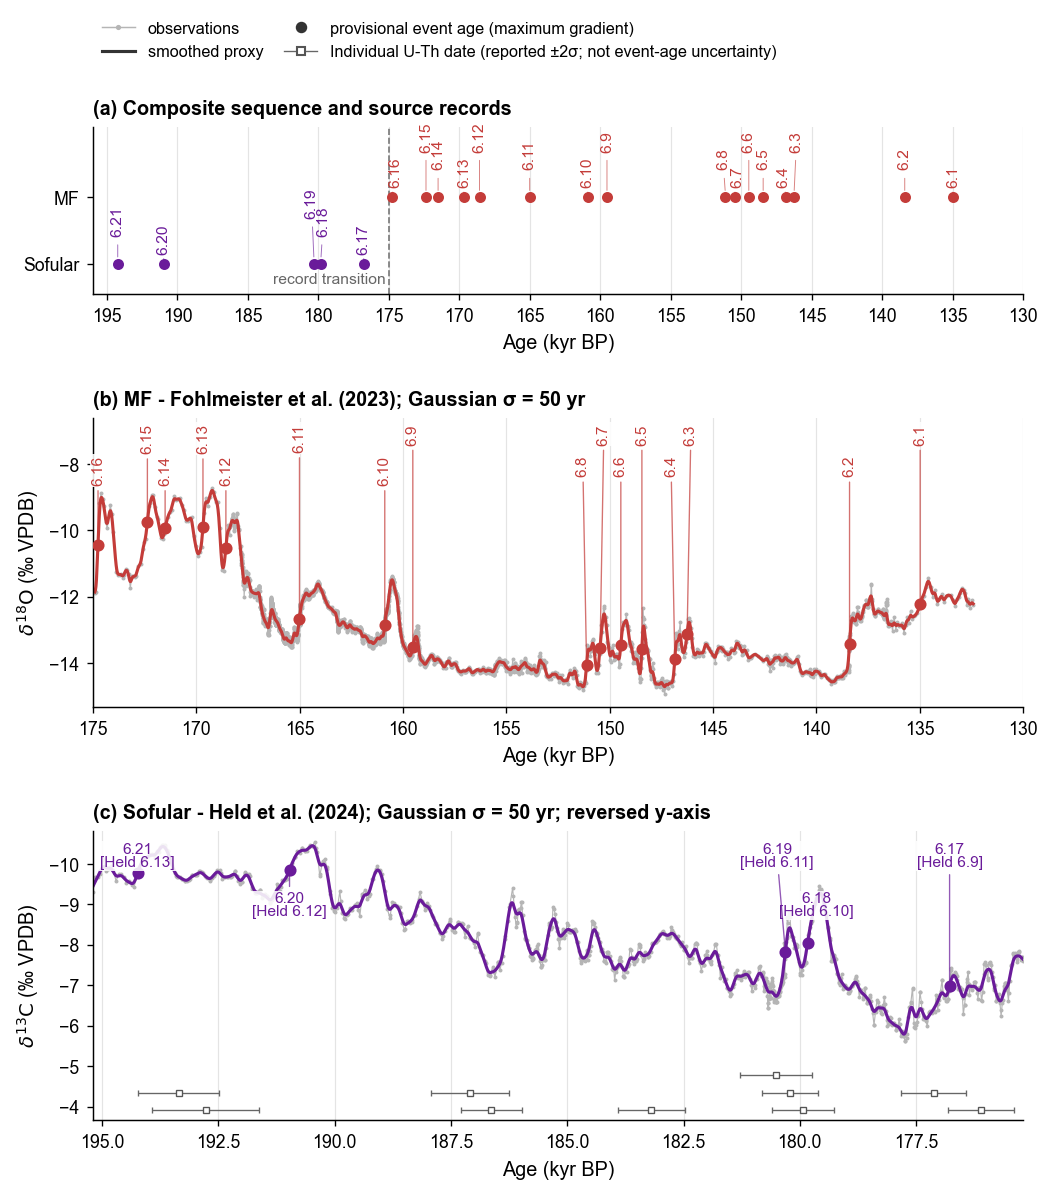

In [6]:
fig = plt.figure(figsize=(180 / 25.4, 205 / 25.4))
grid = fig.add_gridspec(3, 1, height_ratios=[1.15, 2.0, 2.0],
                        left=0.11, right=0.985, bottom=0.065, top=0.885, hspace=0.50)
axes = [fig.add_subplot(grid[i, 0]) for i in range(3)]

# (a) Composite timeline. Alternate label heights prevent dense groups from merging.
ax = axes[0]
for record_id, group in events.groupby("source_record", sort=False):
    spec = RECORD_BY_ID[record_id]
    y = {"MF": 1.0, "Sofular": 0.0}[record_id]
    shifts = close_event_label_shifts(group["event_age_ka_bp"].to_numpy(float))
    for i, (_, event) in enumerate(group.iterrows()):
        age = event["event_age_ka_bp"]
        if abs(age - 175) < 0.5:
            shifts[i] -= 0.22
        ax.scatter(age, y, s=20, linewidth=0.8, marker="o",
                   facecolor=spec.color, edgecolor=spec.color, zorder=3)
        ax.annotate(event["composite_event_display_label"], xy=(age, y + 0.04),
                    xytext=(age + shifts[i], y + 0.14 + 0.27 * (i % 3)),
                    rotation=90, ha="center", va="bottom", fontsize=7.5, color=spec.color,
                    arrowprops=dict(arrowstyle="-", color=spec.color, linewidth=0.45, alpha=0.65))
ax.axvline(175, color="#777777", linestyle="--", linewidth=0.8)
ax.text(175.25, -0.34, "record transition", color="#666666", fontsize=7.5, ha="right", va="bottom")
# BP ages decrease from left to right; only the display direction changes.
ax.set(xlim=(196, 130), ylim=(-0.45, 2.05), yticks=[0, 1],
       yticklabels=["Sofular", "MF"], xlabel="Age (kyr BP)")
ax.set_title("(a) Composite sequence and source records", loc="left")
ax.xaxis.set_major_locator(MultipleLocator(5))
style_axis(ax)

# (b–c) Draw each segment separately to avoid lines across material data gaps.
shown_controls = age_controls["shown_in_composite_figure"].astype(str).str.lower().eq("true")
for ax, letter, spec in zip(axes[1:], "bc", RECORDS):
    for segment in segments[spec.record_id]:
        ax.plot(segment.raw["age_ka_bp"], segment.raw["proxy"], color="#B5B5B5",
                linewidth=0.55, marker=".", markersize=1.8, label="observations", zorder=1)
        ax.plot(segment.grid_age, segment.smoothed[spec.nominal_sigma_ka], color=spec.color,
                linewidth=1.5, label="smoothed proxy", zorder=2)
    local = events.loc[events["source_record"].eq(spec.record_id)]
    shifts = close_event_label_shifts(local["event_age_ka_bp"].to_numpy(float))
    for i, (_, event) in enumerate(local.iterrows()):
        age, proxy = event["event_age_ka_bp"], event["event_proxy_per_mil"]
        ax.scatter(age, proxy, s=24, linewidth=0.9, marker="o",
                   facecolor=spec.color, edgecolor=spec.color, zorder=4)
        label = event["composite_event_display_label"]
        if spec.record_id == "MF":
            y, rotation = 0.98 - 0.11 * (i % 2), 90
        else:
            y, rotation = (0.96 if i % 2 == 0 else 0.79), 0
            label += f"\n[Held {event['source_event_display_label']}]"
        ax.annotate(label, xy=(age, proxy), xycoords="data", xytext=(age + shifts[i], y),
                    textcoords=ax.get_xaxis_transform(), ha="center", va="top", rotation=rotation,
                    fontsize=7.4, color=spec.color, linespacing=0.9, zorder=5,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.88, pad=0.5),
                    arrowprops=dict(arrowstyle="-", color=spec.color, linewidth=0.65, alpha=0.72))

    ax.set_xlim(spec.plot_range_ka[1], spec.plot_range_ka[0])
    ax.set_ylabel(spec.proxy_label)
    ax.set_xlabel("Age (kyr BP)")
    axis_note = "; reversed y-axis" if spec.invert_proxy_axis else ""
    ax.set_title(f"({letter}) {spec.record_id} - {spec.data_source}; "
                 f"Gaussian σ = {spec.nominal_sigma_ka * 1000:.0f} yr{axis_note}", loc="left")
    ymin, ymax = ax.get_ylim()
    if spec.record_id == "Sofular":
        ax.set_ylim(ymin, ymax + 0.22 * (ymax - ymin))
    if spec.invert_proxy_axis:
        ax.invert_yaxis()
    style_axis(ax)

    # U–Th dates occupy rows near the axis, separate from proxy/event markers.
    controls = age_controls.loc[age_controls["record_id"].eq(spec.record_id) & shown_controls]
    controls = controls.sort_values("age_ka_bp").copy()
    controls["lane"] = assign_interval_lanes(controls["age_ka_bp"].to_numpy(float),
                                             controls["age_error_2sigma_ka"].to_numpy(float),
                                             padding=0.01 * np.ptp(ax.get_xlim()))
    for lane, group in controls.groupby("lane", sort=True):
        ax.errorbar(group["age_ka_bp"], np.full(len(group), 0.035 + 0.060 * int(lane)),
                    xerr=group["age_error_2sigma_ka"], transform=ax.get_xaxis_transform(),
                    fmt="s", markersize=3.1, markerfacecolor="white", markeredgecolor="#555555",
                    markeredgewidth=0.65, ecolor="#666666", elinewidth=0.65, capsize=1.5,
                    capthick=0.65, linestyle="none", clip_on=True, zorder=3)

handles = [
    Line2D([0], [0], color="#B5B5B5", marker=".", linewidth=0.7, markersize=3, label="observations"),
    Line2D([0], [0], color="#333333", linewidth=1.5, label="smoothed proxy"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#333333", markeredgecolor="#333333",
           markersize=4.5, label="provisional event age (maximum gradient)"),
    Line2D([0], [0], color="#666666", marker="s", linewidth=0.65, markerfacecolor="white",
           markeredgecolor="#555555", markersize=4,
           label="Individual U-Th date (reported ±2σ; not event-age uncertainty)"),
]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.105, 0.985), ncol=2,
           frameon=False, fontsize=7.8, handlelength=2.0, columnspacing=1.3)
plt.show()

## Save the catalogue and figure

The CSV retains the existing 18 columns. Event ages and tuning bounds are rounded
to 0.001 kyr, resolution to 0.1 year, proxy change to 0.001‰ and peak gradient to
0.01‰/kyr. Unrounded values and all nine picks remain available above.

This cell overwrites three files:

- `data/processed/MIS6_composite_event_record/mis6_composite_event_record.csv`
- `figures/MIS6_composite_event_record/MIS6_composite_event_record.png` (600 dpi)
- `figures/MIS6_composite_event_record/MIS6_composite_event_record.pdf` (vector)

The figure is 180 × 205 mm. Chronology ensembles and the pooled NGRIP–MIS 6
catalogue are separate outputs and are not written by this notebook.

In [7]:
export_columns = (
    "composite_event_id",
    "composite_event_number",
    "composite_event_label",
    "event_age_ka_bp",
    "event_age_status",
    "source_record",
    "source_event_label",
    "source_anchor_age_ka_bp",
    "proxy",
    "data_source",
    "label_source",
    "local_tuning_age_min_ka_bp",
    "local_tuning_age_max_ka_bp",
    "event_age_qc",
    "local_median_resolution_yr",
    "local_flank_change_young_minus_old_per_mil",
    "local_change_qc",
    "peak_gradient_per_mil_per_ka",
)

output = events.rename(columns={"composite_event_display_label": "composite_event_label"}).copy()
output["composite_event_label"] = "MIS " + output["composite_event_label"]
output = output.loc[:, list(export_columns)]
# Apply the existing rounding by physical quantity; keep column order fixed.
for suffix, decimals in [("_ka_bp", 3), ("_yr", 1), ("_per_mil", 3)]:
    columns = [c for c in output if c.endswith(suffix) and pd.api.types.is_numeric_dtype(output[c])]
    output[columns] = output[columns].round(decimals)
output["peak_gradient_per_mil_per_ka"] = output["peak_gradient_per_mil_per_ka"].round(2)
output_csv.parent.mkdir(parents=True, exist_ok=True)
output.to_csv(output_csv, index=False)

figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / f"{figure_stem}.pdf", metadata={
    "Title": "Provisional MIS 6 composite event record",
    "Subject": "Directional-gradient event-age diagnostic",
    "Creator": "MIS6_composite_event_record.ipynb",
})
fig.savefig(figure_dir / f"{figure_stem}.png", dpi=600,
            metadata={"Software": "MIS6_composite_event_record.ipynb"})
copy_pdf_to_paper(figure_dir / f"{figure_stem}.pdf")
print(f"Saved {len(output)} events to {output_csv}")
print(f"Saved PNG and PDF to {figure_dir}")
print("Events flagged for review:", ", ".join(events.loc[
    events["event_age_qc"].eq("review"), "composite_event_display_label"
]))

Saved 21 events to data/processed/MIS6_composite_event_record/mis6_composite_event_record.csv
Saved PNG and PDF to figures/MIS6_composite_event_record
Events flagged for review: 6.1, 6.10, 6.14, 6.16
